## SARIMAX

In [1]:
import pandas as pd

finsec_data=pd.read_csv('../feature_engineering/stocks_sectors/financial_services/financial_services_sector')

finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


In [2]:
fin_data=finsec_data[['date','weighted_sector_returns', 'sector_index','sector_volume']]
fin_data

,date,weighted_sector_returns,sector_index,sector_volume
0,2017-01-03,0.000000,100.000000,48125518.0
1,2017-01-04,0.353432,100.353432,26705191.0
2,2017-01-05,-0.182223,100.170565,66991076.0
3,2017-01-06,1.397196,101.570144,97521276.0
4,2017-01-09,3.645896,105.273286,99013315.0
...,...,...,...,...
2258,2026-07-13,-0.746327,2695.019313,290562049.0
2259,2026-07-14,0.906947,2719.461701,163509442.0
2260,2026-07-15,0.779799,2740.668037,258362267.0
2261,2026-07-16,1.505893,2781.939574,261040578.0


In [3]:
fin_data['date']=pd.to_datetime(fin_data['date'])
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
 2   sector_index             2263 non-null   float64       
 3   sector_volume            2263 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 70.8 KB


We now have the financial data. Lets get the exogeneous data. We will use volume percent change and we will have to lag by 1 day because if we are predicting tomorrows returns we cannot have information of its volume yet.

In [5]:
fin_data['sector_vol_pct_change']=fin_data['sector_volume'].pct_change()*100

fin_data

,date,weighted_sector_returns,sector_index,sector_volume,sector_vol_pct_change
0,2017-01-03,0.000000,100.000000,48125518.0,NaN
1,2017-01-04,0.353432,100.353432,26705191.0,-44.509291
2,2017-01-05,-0.182223,100.170565,66991076.0,150.854135
3,2017-01-06,1.397196,101.570144,97521276.0,45.573533
4,2017-01-09,3.645896,105.273286,99013315.0,1.529963
...,...,...,...,...,...
2258,2026-07-13,-0.746327,2695.019313,290562049.0,19.893527
2259,2026-07-14,0.906947,2719.461701,163509442.0,-43.726497
2260,2026-07-15,0.779799,2740.668037,258362267.0,58.010610
2261,2026-07-16,1.505893,2781.939574,261040578.0,1.036649


In [6]:
## shift the volume pct change
fin_data_adj=fin_data.copy()

In [7]:
fin_data_adj['sector_vol_pct_change']=fin_data_adj['sector_vol_pct_change'].shift(1)

In [9]:
fin_data_adj=fin_data_adj.dropna()

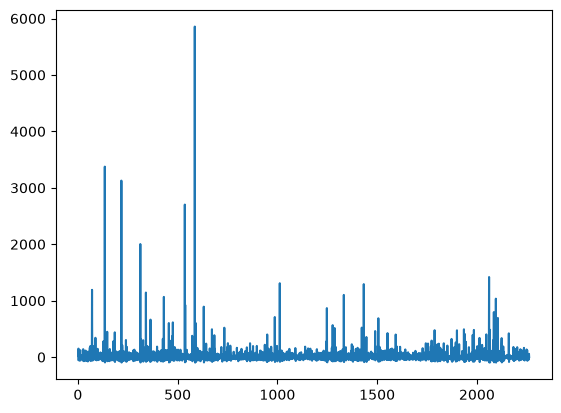

In [10]:
## Lets inspect the volume change.
import matplotlib.pyplot as plt

plt.plot(fin_data_adj['sector_vol_pct_change'])
plt.show()

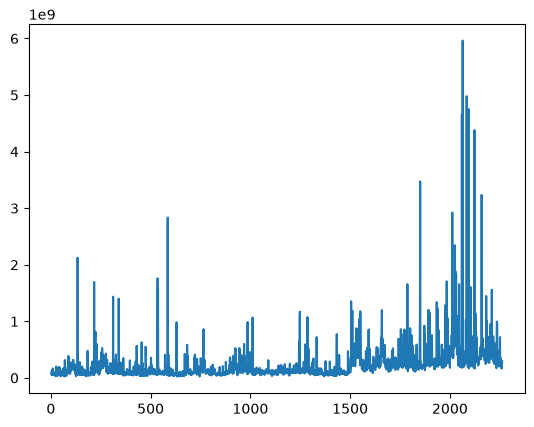

In [11]:
## Lets inspect the volume change.
import matplotlib.pyplot as plt

plt.plot(fin_data_adj['sector_volume'])
plt.show()

In [14]:
# Fitting a SARIMAX model 
import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

train = fin_data_adj['weighted_sector_returns'][:-100]
test = fin_data_adj['weighted_sector_returns'][-100:]

# 2, 1, 1, 3, 2, 2
mod = SARIMAX(
endog=fin_data_adj['weighted_sector_returns'][:-100],
exog=fin_data_adj['sector_vol_pct_change'][:-100],
order=(2,1,1),
seasonal_order=(3,2,2,10),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=100, exog = fin_data_adj['sector_vol_pct_change'][-100:])


c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


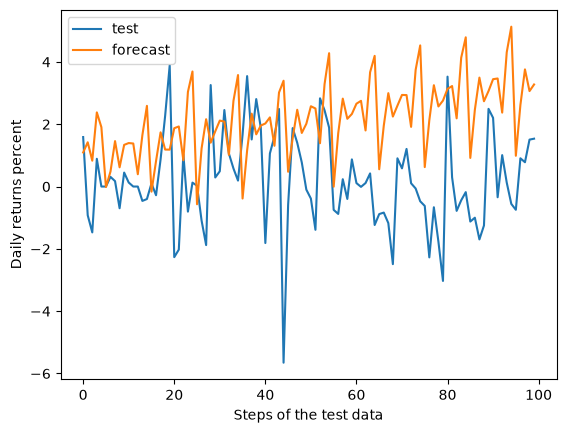

-2.384078906021915

In [15]:
plt.plot(list(test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Daily returns percent')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)

Very poor. Lets try using the actual sector volumes itself rather than the change.

In [16]:
# Fitting a SARIMAX model 
import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

train = fin_data_adj['weighted_sector_returns'][:-100]
test = fin_data_adj['weighted_sector_returns'][-100:]

# 2, 1, 1, 3, 2, 2
mod = SARIMAX(
endog=fin_data_adj['weighted_sector_returns'][:-100],
exog=fin_data_adj['sector_volume'][:-100],
order=(2,1,1),
seasonal_order=(3,2,2,10),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=100, exog = fin_data_adj['sector_volume'][-100:])


c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


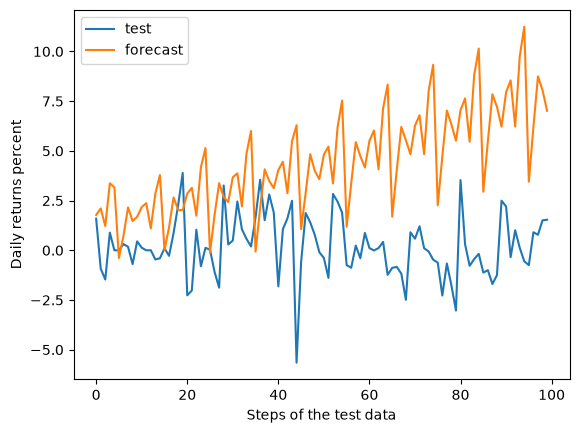

-10.695832274944634

In [17]:
plt.plot(list(test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Daily returns percent')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)

Lets check sector_index against sector-volume

In [24]:
# Fitting a SARIMAX model 
import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

train = fin_data_adj['sector_index'][:-10]
test = fin_data_adj['sector_index'][-10:]

# 2, 1, 1, 3, 2, 2
mod = SARIMAX(
endog=fin_data_adj['sector_index'][:-10],
exog=fin_data_adj['sector_volume'][:-10],
order=(2,1,1),
seasonal_order=(3,2,2,10),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10, exog = fin_data_adj['sector_volume'][-10:])


c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


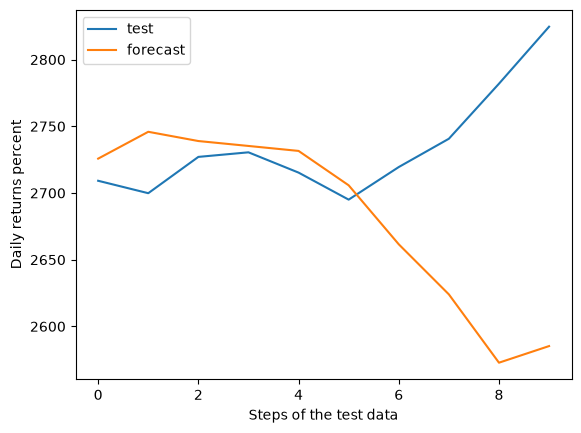

-7.3506572877224094

In [25]:
plt.plot(list(test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Daily returns percent')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)

Lets find out other exogeneous variables that could influence the returns or the sector_index

In [26]:
macro_data=pd.read_csv('../macroeconomic_data/populated_cleaned_macro_data_adjusted')
macro_data

,Quarter,Month,date,consumer_price_index(CPI)_monthly,Crude Oil Price_monthly,Domestic Production_monthly,Crude Oil Export_monthly,Inflation_allItemsAverage_monthly,Money Supply(M2)_monthly,currency in circulation_monthly,...,gdp_svc_Other Services_quarterly,GDP at Current Basic Prices_quarterly,Net Taxes on Products_quarterly,GDP at Current Market Prices_quarterly,foreign_reserve_Gross(USD)_monthly,foreign_reserve_Liquid(USD)_monthly,Year,Month_idx,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
0,Q2,April,2017-04-04,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.030715e+10,2.963927e+10
1,Q2,April,2017-04-05,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.031831e+10,2.965163e+10
2,Q2,April,2017-04-06,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.032576e+10,2.966022e+10
3,Q2,April,2017-04-07,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.034555e+10,2.968121e+10
4,Q2,April,2017-04-10,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.036654e+10,2.970295e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2251,Q2,June,2026-06-24,983.932019,112.63,1.53,1.08,18.36,1.292010e+08,5689981.32,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026,6,5.117392e+10,5.050894e+10
2252,Q2,June,2026-06-25,983.932019,112.63,1.53,1.08,18.36,1.292010e+08,5689981.32,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026,6,5.120571e+10,5.054315e+10
2253,Q2,June,2026-06-26,983.932019,112.63,1.53,1.08,18.36,1.292010e+08,5689981.32,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026,6,5.124834e+10,5.058818e+10
2254,Q2,June,2026-06-29,983.932019,112.63,1.53,1.08,18.36,1.292010e+08,5689981.32,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026,6,5.129261e+10,5.063481e+10


In [27]:
macro_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2256 entries, 0 to 2255
Data columns (total 84 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Quarter                                                                     2256 non-null   str    
 1   Month                                                                       2256 non-null   str    
 2   date                                                                        2256 non-null   str    
 3   consumer_price_index(CPI)_monthly                                           2256 non-null   float64
 4   Crude Oil Price_monthly                                                     2256 non-null   float64
 5   Domestic Production_monthly                                                 2256 non-null   float64
 6   Crude Oil Export_monthly                                   

In [28]:
macro_data.rename(columns={' gdp_Fishing_quarterly':'gdp_Fishing_quarterly'}, inplace=True)

In [29]:
macro_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2256 entries, 0 to 2255
Data columns (total 84 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Quarter                                                                     2256 non-null   str    
 1   Month                                                                       2256 non-null   str    
 2   date                                                                        2256 non-null   str    
 3   consumer_price_index(CPI)_monthly                                           2256 non-null   float64
 4   Crude Oil Price_monthly                                                     2256 non-null   float64
 5   Domestic Production_monthly                                                 2256 non-null   float64
 6   Crude Oil Export_monthly                                   

In [30]:
macro_data['date']=pd.to_datetime(macro_data['date'])

In [31]:
macro_data['date'].info()

<class 'pandas.Series'>
RangeIndex: 2256 entries, 0 to 2255
Series name: date
Non-Null Count  Dtype         
--------------  -----         
2256 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 17.8 KB


In [32]:
finsec_data['date']=pd.to_datetime(finsec_data['date'])

In [33]:
## Now we will join the data by date
# Assume both dataframes have an exact 'date' column match
merged_df = pd.merge(finsec_data, macro_data, on="date", how="left")


In [34]:
merged_df

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume,Quarter,Month,consumer_price_index(CPI)_monthly,Crude Oil Price_monthly,...,gdp_svc_Other Services_quarterly,GDP at Current Basic Prices_quarterly,Net Taxes on Products_quarterly,GDP at Current Market Prices_quarterly,foreign_reserve_Gross(USD)_monthly,foreign_reserve_Liquid(USD)_monthly,Year,Month_idx,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2286,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2287,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2288,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2289,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2291 entries, 0 to 2290
Data columns (total 89 columns):
 #   Column                                                                      Non-Null Count  Dtype         
---  ------                                                                      --------------  -----         
 0   date                                                                        2291 non-null   datetime64[us]
 1   sector                                                                      2291 non-null   str           
 2   weighted_sector_returns                                                     2291 non-null   float64       
 3   n_stocks_contributing                                                       2291 non-null   float64       
 4   sector_index                                                                2291 non-null   float64       
 5   sector_volume                                                               2291 non-null   float64       
 6   Qua

In [36]:
merged_df_clean=merged_df.dropna()
merged_df_clean.shape

(2151, 89)

In [39]:
merged_df_clean

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume,Quarter,Month,consumer_price_index(CPI)_monthly,Crude Oil Price_monthly,...,gdp_svc_Other Services_quarterly,GDP at Current Basic Prices_quarterly,Net Taxes on Products_quarterly,GDP at Current Market Prices_quarterly,foreign_reserve_Gross(USD)_monthly,foreign_reserve_Liquid(USD)_monthly,Year,Month_idx,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
65,2017-04-04,financial_services,-0.295235,21.0,104.721159,45091739.0,Q2,April,204.456610,52.13,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.030715e+10,2.963927e+10
66,2017-04-05,financial_services,0.584640,21.0,105.333401,96410309.0,Q2,April,204.456610,52.13,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.031831e+10,2.965163e+10
67,2017-04-06,financial_services,-0.282732,21.0,105.035590,101585127.0,Q2,April,204.456610,52.13,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.032576e+10,2.966022e+10
68,2017-04-07,financial_services,0.624710,21.0,105.691757,51494340.0,Q2,April,204.456610,52.13,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.034555e+10,2.968121e+10
69,2017-04-10,financial_services,-0.184162,20.0,105.497113,24515324.0,Q2,April,204.456610,52.13,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.036654e+10,2.970295e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2273,2026-06-24,financial_services,-0.780891,35.0,2738.664567,265867729.0,Q2,June,983.932019,112.63,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026.0,6.0,5.117392e+10,5.050894e+10
2274,2026-06-25,financial_services,-0.441686,35.0,2726.568271,231997356.0,Q2,June,983.932019,112.63,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026.0,6.0,5.120571e+10,5.054315e+10
2275,2026-06-26,financial_services,-0.179215,35.0,2721.681843,203570410.0,Q2,June,983.932019,112.63,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026.0,6.0,5.124834e+10,5.058818e+10
2276,2026-06-29,financial_services,-1.123746,35.0,2691.097044,480278073.0,Q2,June,983.932019,112.63,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026.0,6.0,5.129261e+10,5.063481e+10


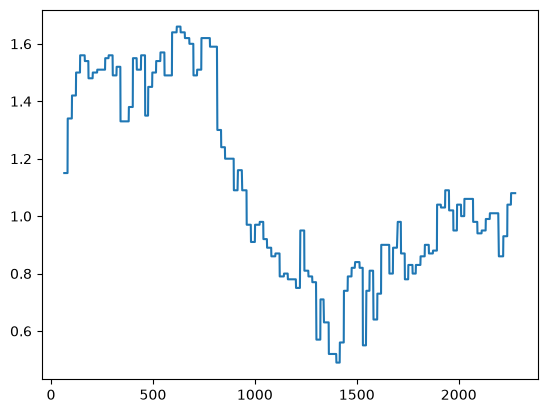

In [40]:

plt.plot(merged_df_clean['Crude Oil Export_monthly'])

plt.show()

In [44]:
## The needed features for this training (Check Cloud AI for explanation)
X_y_finance_features = [
    #target feature
    'weighted_sector_returns',
    'sector_index',
    'sector_volume',  # consider lagging — see caveat below

    # Prices / inflation
    'consumer_price_index(CPI)_monthly',
    'Inflation_allItemsAverage_monthly',
    'Premium_Motor_Spirit(PMS)_monthly',

    # Oil
    'Crude Oil Price_monthly',
    'Domestic Production_monthly',
    'Crude Oil Export_monthly',

    # Money supply / banking system
    'Money Supply(M2)_monthly',
    'currency in circulation_monthly',
    'bank reserves_monthly',
    'netForeignAssets_monthly',
    'netDomesticAssets_monthly',
    'netDomesticCredit_monthly',
    'creditToGovernment_monthly',
    'creditToPrivateSector_monthly',

    # Interest rates
    'MonetaryPolicyRate_monthly',
    'TreasuryBillRate_monthly',
    'Lending_Rate_monthly',

    # Exchange rate
    'Exchange_Rate(USD-EOP)_monthly',

    # Broad economy GDP
    'GDP_AGRICULTURE(agric)_quarterly',
    'GDP_INDUSTRY(ind)_quarterly',
    'GDP at Current Market Prices_quarterly',

    # Financial sector-specific GDP
    'gdp_svc_FI_Financial Institutions_quarterly',

    # Foreign reserves (pick one frequency — daily shown here)
    'foreign_reserve_gross(USD)_daily',
    'foreign_reserve_liquid(USD)_daily',
]


In [45]:
merged_df_selected=merged_df_clean[X_y_finance_features]

In [46]:
merged_df_selected.corr()

,weighted_sector_returns,sector_index,sector_volume,consumer_price_index(CPI)_monthly,Inflation_allItemsAverage_monthly,Premium_Motor_Spirit(PMS)_monthly,Crude Oil Price_monthly,Domestic Production_monthly,Crude Oil Export_monthly,Money Supply(M2)_monthly,...,MonetaryPolicyRate_monthly,TreasuryBillRate_monthly,Lending_Rate_monthly,Exchange_Rate(USD-EOP)_monthly,GDP_AGRICULTURE(agric)_quarterly,GDP_INDUSTRY(ind)_quarterly,GDP at Current Market Prices_quarterly,gdp_svc_FI_Financial Institutions_quarterly,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
weighted_sector_returns,1.000000,0.036199,0.078865,0.036788,0.057614,0.037428,-0.040990,-0.030321,-0.030321,0.036900,...,0.044230,0.027193,0.027322,0.038416,0.033296,0.033946,0.033132,0.034103,-0.060531,-0.061865
sector_index,0.036199,1.000000,0.399787,0.921048,0.516784,0.921026,0.297787,-0.292869,-0.292869,0.901544,...,0.844583,0.585983,0.562053,0.830014,0.853624,0.694188,0.949407,0.856318,0.403362,0.399220
sector_volume,0.078865,0.399787,1.000000,0.389445,0.264216,0.383812,0.060906,-0.109435,-0.109435,0.384129,...,0.379240,0.259442,0.260966,0.368481,0.371666,0.262090,0.397685,0.369327,0.110662,0.108387
consumer_price_index(CPI)_monthly,0.036788,0.921048,0.389445,1.000000,0.709470,0.938913,0.375995,-0.512593,-0.512593,0.993408,...,0.926271,0.555632,0.418807,0.942293,0.878492,0.870827,0.961467,0.942385,0.213047,0.206704
Inflation_allItemsAverage_monthly,0.057614,0.516784,0.264216,0.709470,1.000000,0.642471,0.360213,-0.540425,-0.540425,0.746231,...,0.764461,0.528143,0.296194,0.796574,0.507435,0.717676,0.561274,0.737271,-0.153135,-0.166334
Premium_Motor_Spirit(PMS)_monthly,0.037428,0.921026,0.383812,0.938913,0.642471,1.000000,0.270276,-0.300621,-0.300621,0.940199,...,0.926396,0.663997,0.585364,0.921414,0.792128,0.781481,0.899733,0.906764,0.260732,0.252472
Crude Oil Price_monthly,-0.040990,0.297787,0.060906,0.375995,0.360213,0.270276,1.000000,-0.585350,-0.585350,0.349511,...,0.251566,0.072344,-0.122648,0.259164,0.215951,0.525015,0.297553,0.354519,0.235315,0.233641
Domestic Production_monthly,-0.030321,-0.292869,-0.109435,-0.512593,-0.540425,-0.300621,-0.585350,1.000000,1.000000,-0.489953,...,-0.293811,0.156622,0.413686,-0.391947,-0.419765,-0.701822,-0.420385,-0.438209,0.222329,0.214006
Crude Oil Export_monthly,-0.030321,-0.292869,-0.109435,-0.512593,-0.540425,-0.300621,-0.585350,1.000000,1.000000,-0.489953,...,-0.293811,0.156622,0.413686,-0.391947,-0.419765,-0.701822,-0.420385,-0.438209,0.222329,0.214006
Money Supply(M2)_monthly,0.036900,0.901544,0.384129,0.993408,0.746231,0.940199,0.349511,-0.489953,-0.489953,1.000000,...,0.945928,0.600021,0.440887,0.971839,0.851138,0.863730,0.939999,0.953609,0.187968,0.180601


Weak correlations but let us try.

In [53]:
merged_df_selected

,weighted_sector_returns,sector_index,sector_volume,consumer_price_index(CPI)_monthly,Inflation_allItemsAverage_monthly,Premium_Motor_Spirit(PMS)_monthly,Crude Oil Price_monthly,Domestic Production_monthly,Crude Oil Export_monthly,Money Supply(M2)_monthly,...,MonetaryPolicyRate_monthly,TreasuryBillRate_monthly,Lending_Rate_monthly,Exchange_Rate(USD-EOP)_monthly,GDP_AGRICULTURE(agric)_quarterly,GDP_INDUSTRY(ind)_quarterly,GDP at Current Market Prices_quarterly,gdp_svc_FI_Financial Institutions_quarterly,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
65,-0.295235,104.721159,45091739.0,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.030715e+10,2.963927e+10
66,0.584640,105.333401,96410309.0,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.031831e+10,2.965163e+10
67,-0.282732,105.035590,101585127.0,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.032576e+10,2.966022e+10
68,0.624710,105.691757,51494340.0,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.034555e+10,2.968121e+10
69,-0.184162,105.497113,24515324.0,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.036654e+10,2.970295e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2273,-0.780891,2738.664567,265867729.0,983.932019,18.36,1596.245819,112.63,1.53,1.08,1.292010e+08,...,26.5,15.95,19.10,1373.2545,20058.337297,22442.618713,113186.87012,3844.433287,5.117392e+10,5.050894e+10
2274,-0.441686,2726.568271,231997356.0,983.932019,18.36,1596.245819,112.63,1.53,1.08,1.292010e+08,...,26.5,15.95,19.10,1373.2545,20058.337297,22442.618713,113186.87012,3844.433287,5.120571e+10,5.054315e+10
2275,-0.179215,2721.681843,203570410.0,983.932019,18.36,1596.245819,112.63,1.53,1.08,1.292010e+08,...,26.5,15.95,19.10,1373.2545,20058.337297,22442.618713,113186.87012,3844.433287,5.124834e+10,5.058818e+10
2276,-1.123746,2691.097044,480278073.0,983.932019,18.36,1596.245819,112.63,1.53,1.08,1.292010e+08,...,26.5,15.95,19.10,1373.2545,20058.337297,22442.618713,113186.87012,3844.433287,5.129261e+10,5.063481e+10


In [58]:
endog = merged_df_selected['sector_index'][:-10]


In [59]:
exog = merged_df_selected.drop(columns=['weighted_sector_returns','sector_index'])[:-10]

In [61]:
# Fitting a SARIMAX model 
import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

import warnings

warnings.filterwarnings('ignore')

# 2, 1, 1, 3, 2, 2
mod = SARIMAX(
endog=endog,
exog=exog,
order=(2,1,1),
seasonal_order=(3,2,2,10),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10, exog = merged_df_selected.drop(columns=['weighted_sector_returns','sector_index'])[-10:])


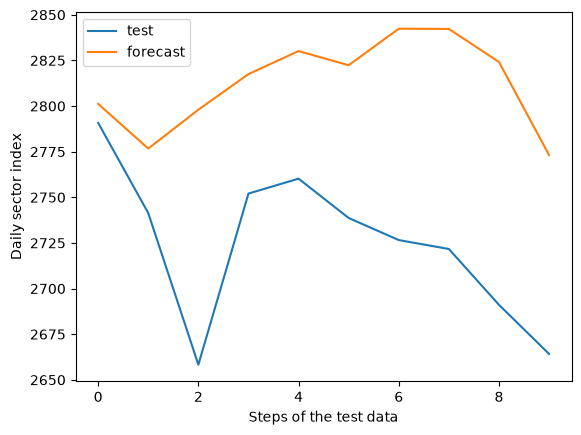

-4.953104050251783

In [62]:
plt.plot(list(merged_df_selected['sector_index'][-10:]))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Daily sector index')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)

THis tells you that the whole correlation being positive is just the trend.

Let us perform a percent_change on these columns Before this, we will check out weighted sector returns.

In [63]:
# Fitting a SARIMAX model 
import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

import warnings

warnings.filterwarnings('ignore')

endog = merged_df_selected['weighted_sector_returns'][:-10]
exog = merged_df_selected.drop(columns=['weighted_sector_returns','sector_index'])[:-10]

# 2, 1, 1, 3, 2, 2
mod = SARIMAX(
endog=endog,
exog=exog,
order=(2,1,1),
seasonal_order=(3,2,2,10),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10, exog = merged_df_selected.drop(columns=['weighted_sector_returns','sector_index'])[-10:])


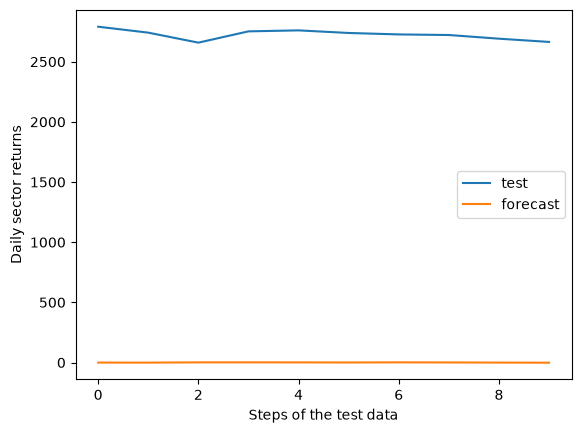

-5159.194847920147

In [64]:
plt.plot(list(merged_df_selected['sector_index'][-10:]))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Daily sector returns')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)

Very poor!!!
